# Multi-Agent Systems: Swarm

In the previous notebook, we saw how to create a multi-agent system with a supervisor agent that oversees the work of other agents. The supervisor agent decides which agent is best suited to handle the task and delegates the task to the chosen agent. The chosen agent then completes the task and returns the result to the supervisor agent, which in turn returns the result to the user. In this notebook, we will see another way to facilitate multi-agent collaboration: The swarm. The swarm is not an agent itself, but rather a collection of agents that work together to solve a task. Here, each agent is capable of passing the execution to another agent in the swarm. This way, the swarm can handle complex tasks that require the use of multiple agents. The swarm will decide which agent to use based on the task and delegate the task to the chosen agent. Once the chosen agent has completed the task, it will return the result to the swarm, which will then return the result to the user.

## Imports, Environment, Chat Model, and Tools

As always, we start by importing the necessary libraries and setting up the environment.

In [2]:
import os
import dotenv
from typing import List
from IPython.display import Image
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_swarm, create_handoff_tool
from langfuse.langchain import CallbackHandler

# Load environment variables from .env file.
dotenv.load_dotenv()

# Initialize the Langfuse handler
langfuse_handler = CallbackHandler()

# Initialize the chat model
model = init_chat_model(os.environ["LANGCHAIN_CHAT_MODEL_ANTHROPIC"])

Exception while exporting Span.
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/connection.py", line 199, in _new_conn
    sock = connection.create_connection(
        (self._dns_host, self.port),
    ...<2 lines>...
        socket_options=self.socket_options,
    )
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
    ~~~~~~~~~~~~^^^^
ConnectionRefusedError: [Errno 61] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/connectionpool.py", line 789, in urlopen
    response = self._ma

In [3]:
class MathToolInput(BaseModel):
    """Input for the math tool."""
    operand1: float = Field(..., description="The first operand for the math operation.")
    operand2: float = Field(..., description="The second operand for the math operation.")
    operator: str = Field(..., description="The operator for the math operation", enumerate=["+", "-", "*", "/"])

@tool
def math_tool(input: MathToolInput) -> float:
    """Perform a math operation based on the input."""
    if input.operator == "+":
        return input.operand1 + input.operand2
    elif input.operator == "-":
        return input.operand1 - input.operand2
    elif input.operator == "*":
        return input.operand1 * input.operand2
    elif input.operator == "/":
        if input.operand2 == 0:
            raise ValueError("Cannot divide by zero.")
        return input.operand1 / input.operand2
    else:
        raise ValueError(f"Unknown operator: {input.operator}")


class SortToolInput(BaseModel):
    """Input for the sort tool."""
    numbers: List[float] = Field(..., description="A list of numbers to sort.")
    order: str = Field(..., description="The order to sort the numbers", enumerate=["asc", "desc"])

@tool
def sort_tool(input: SortToolInput) -> List[float]:
    """Sort a list of numbers in ascending or descending order."""
    if input.order == "asc":
        return sorted(input.numbers)
    elif input.order == "desc":
        return sorted(input.numbers, reverse=True)
    else:
        raise ValueError(f"Unknown order: {input.order}")

/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42369/2030071592.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'enumerate'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  operator: str = Field(..., description="The operator for the math operation", enumerate=["+", "-", "*", "/"])
/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42369/2030071592.py:27: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'enumerate'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  order: str = Field(..., description="The order to sort the numbers", enumerate=["asc", "desc"])


## The introduction of handoff tools

We will introduce a couple of new tools for the agents to use. The handoff tools allow an agent to pass the execution to another agent in the swarm. Thus handing off the execution gets reduced to a tool call.

In [4]:
transfer_to_sort_agent = create_handoff_tool(
    agent_name="sort_agent",
    description="Transfers the task to the sort agent.",
)

transfer_to_math_agent = create_handoff_tool(
    agent_name="math_agent",
    description="Transfers the task to the math agent.",
)

## Creating two Agents and turning them into a Swarm

Now creating a swarm is as easy as creating two agents and adding the handoff tools to their toolset. Each agent can now pass the execution to the other agent in the swarm.

/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42369/1311512112.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent = create_react_agent(
/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42369/1311512112.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  sort_agent = create_react_agent(


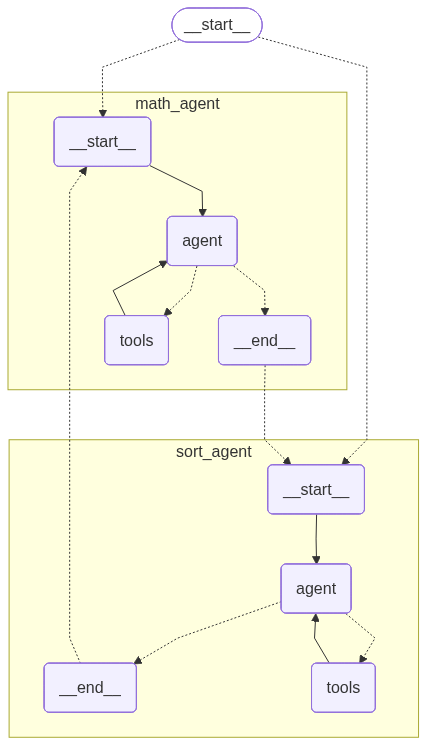

In [7]:
math_agent = create_react_agent(
    model=model,
    tools=[math_tool, transfer_to_sort_agent],
    prompt="You are a helpful assistant that can perform math operations.",
    name="math_agent"
)

sort_agent = create_react_agent(
    model=model,
    tools=[sort_tool, transfer_to_math_agent],
    prompt="You are a helpful assistant that can sort numbers.",
    name="sort_agent"
)

swarm = create_swarm(
    agents=[math_agent, sort_agent],
    default_active_agent="math_agent",
).compile()

# Render the graph.
display(Image(swarm.get_graph(xray=True).draw_mermaid_png()))

In [8]:
print("Invoking swarm...")
for chunk in swarm.stream({
    "messages": [HumanMessage(content="Find out the sum of 123456789 and 987654321, then sort the numbers 10, 5, 3, -24, 0 in descending order.")],
    },
    config={"callbacks": [langfuse_handler]},
):
    print(chunk)
    print("\n")

Invoking swarm...


ModuleNotFoundError: No module named 'langchain_core.messages.block_translators.langchain_v0'

# Done.